<a href="https://colab.research.google.com/github/idhayaig-cmd/Social-Media-Engagement-Analytics-Using-Python-/blob/main/Social_Media_Engagement_Analytics_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import libraries**

In [ ]:
!pip install pandas numpy seaborn requests

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import requests

# **2. Load the dataset**

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv")

# **3. Data Exploration**

In [ ]:
#first 5 row:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
#Last 5 row:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [ ]:
print("\nShape:", df.shape)


Shape: (5000, 19)


In [ ]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')


In [ ]:
print("\nData types:")
display(df.dtypes)


Data types:


,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


# **Data Formatting**

In [ ]:
#age
df['age'] = df['age'].astype('Int64')

#likes
df['likes'] = df['likes'].astype('int64')

#comments
df['comments'] = df['comments'].astype('int64')

#Shares
df['shares'] = df['shares'].astype('int64')

df['posted_at'] = pd.to_datetime(df['posted_at'])

In [ ]:
categorical_cols = ['gender', 'country', 'post_type','post_category','device_type','sentiment']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [ ]:
display(df.dtypes)

,0
user_id,int64
age,Int64
gender,category
country,category
post_id,int64
post_type,category
post_category,category
likes,int64
comments,int64
shares,int64


# **4) Check Data Quality**

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


# **5) Handling Missing Values**

In [ ]:
# Missing values
missing = df.isnull().sum()
print(missing[missing > 0])

gender       150
sentiment    150
dtype: int64


In [ ]:
missing = df.isnull().mean()*100
print(missing[missing > 0])

gender       3.0
sentiment    3.0
dtype: float64


In [ ]:
df['gender'].mode()
df['sentiment'].mode()

,sentiment
0,positive


In [ ]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
# Extract the number of hashtags
df['hashtag_count'] = df['hashtags'].str.count('#')
display(df[['hashtags', 'hashtag_count']].head(10))

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
5,#fitness,1
6,#music,1
7,#travel #music #fitness,3
8,#music #fun #fitness,3
9,#lifestyle #love,2


In [ ]:
df["sentiment"]= df["sentiment"].str.strip().str.lower()
df.sentiment

,sentiment
0,negative
1,negative
2,positive
3,negative
4,negative
...,...
4995,positive
4996,negative
4997,positive
4998,positive


In [ ]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

# **6) Data Exploration using Pandas**

In [ ]:
print("\n info:")
df.info()


 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   Int64         
 2   gender            5000 non-null   category      
 3   country           5000 non-null   category      
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   category      
 6   post_category     5000 non-null   category      
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified     

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,5000.0,54561.890800,26090.370121,10055.000000,32309.500000,54374.500000,77180.500000,99963.000000
age,4850.0,38.454021,14.912381,13.000000,26.000000,38.000000,51.000000,64.000000
post_id,5000.0,548042.909000,260646.957267,100068.000000,322543.500000,548077.500000,771574.500000,999455.000000
likes,4850.0,10107.043711,5789.819252,10.000000,5068.500000,10105.500000,15115.000000,19998.000000
comments,4850.0,1502.195670,869.537889,0.000000,760.000000,1497.000000,2256.000000,2999.000000
shares,4850.0,1002.629485,579.615158,0.000000,498.000000,1012.000000,1501.000000,1999.000000
watch_time_sec,5000.0,4014.503200,2308.096459,0.000000,2017.750000,4034.500000,6020.250000,7998.000000
impression_count,5000.0,50013.732800,28844.939104,105.000000,24988.250000,49934.500000,74662.250000,99995.000000
follower_count,5000.0,393698.224800,230927.884535,87.000000,194480.000000,388982.000000,589744.250000,799533.000000
engagement_rate,5000.0,0.964356,5.318029,0.006363,0.145781,0.253896,0.504794,191.504348


In [ ]:
print("\nSummary statistics:")
display(df.describe(include="object").T)


Summary statistics:


,count,unique,top,freq
gender,5000,3,Male,1849
country,5000,10,India,535
post_type,5000,4,reel,1283
post_category,5000,8,fitness,675
posted_at,5000,729,26-12-2023,16
device_type,5000,3,mobile,1684
sentiment,5000,3,positive,2513
hashtags,5000,761,#tech,201


In [ ]:
# Analyze categorical distributions

for col in ["gender", "country", "post_type", "post_category", "device_type", "sentiment", "is_verified"]:
    print(f"\n----- {col.upper()} -----")
    print("Unique Values:", df[col].unique())
    print("Number of Categories:", df[col].nunique())
    print("Value Counts:")
    print(df[col].value_counts())


----- GENDER -----
Unique Values: ['Female' 'Male' 'Other' nan]
Number of Categories: 3
Value Counts:
gender
Male      1699
Other     1581
Female    1570
Name: count, dtype: int64

----- COUNTRY -----
Unique Values: ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
Number of Categories: 10
Value Counts:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

----- POST_TYPE -----
Unique Values: ['image' 'reel' 'text' 'video']
Number of Categories: 4
Value Counts:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

----- POST_CATEGORY -----
Unique Values: ['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
Number of Categories: 8
Value Counts:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    60

In [ ]:
#Create a correlation matrix for numeric fields.
df.select_dtypes(include=['int64', 'float64']).corr()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
user_id,1.000000,-0.006789,0.020051,0.026228,-0.033874,0.014004,-0.016847,0.015326,0.010124,-0.004282
age,-0.006789,1.000000,-0.013353,-0.037371,-0.007491,0.014348,0.005677,0.013513,-0.025416,0.008044
post_id,0.020051,-0.013353,1.000000,0.014773,-0.010724,0.001901,0.018374,-0.007709,-0.002844,0.010139
likes,0.026228,-0.037371,0.014773,1.000000,-0.018980,0.004799,0.008837,0.008067,-0.023331,0.093555
comments,-0.033874,-0.007491,-0.010724,-0.018980,1.000000,0.006310,-0.016616,-0.009537,-0.011921,0.000046
shares,0.014004,0.014348,0.001901,0.004799,0.006310,1.000000,0.014898,-0.005178,-0.010891,0.021804
watch_time_sec,-0.016847,0.005677,0.018374,0.008837,-0.016616,0.014898,1.000000,-0.004335,0.002761,-0.001148
impression_count,0.015326,0.013513,-0.007709,0.008067,-0.009537,-0.005178,-0.004335,1.000000,-0.015513,-0.232226
follower_count,0.010124,-0.025416,-0.002844,-0.023331,-0.011921,-0.010891,0.002761,-0.015513,1.000000,0.002292
engagement_rate,-0.004282,0.008044,0.010139,0.093555,0.000046,0.021804,-0.001148,-0.232226,0.002292,1.000000


In [ ]:
# GroupBy
display(df.groupby('post_type')['likes'].mean())
df.groupby('country')['impression_count'].agg(['mean', 'count'])


,likes
post_type,
image,10104.848560
reel,10035.341680
text,10099.975124
video,10190.972292


,mean,count
country,,
Australia,48346.383367,493
Brazil,49193.174603,504
Canada,48703.150097,513
France,51727.673387,496
Germany,48605.406122,490
India,52462.386916,535
Japan,49616.135593,472
UAE,48928.413519,503
UK,51119.393509,493


# **7)Data Wrangling**

In [ ]:
# 1. Create hashtag count
df['hashtag_count'] = df['hashtags'].str.count('#')
display(df[['hashtags', 'hashtag_count']].head(10))

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
5,#fitness,1
6,#music,1
7,#travel #music #fitness,3
8,#music #fun #fitness,3
9,#lifestyle #love,2


In [ ]:
# 2. Create engagement score
df['engagement_score'] = (df['likes'] +df['comments'] +df['shares'])
display(df['engagement_score'])

,engagement_score
0,8522.0
1,16163.0
2,6161.0
3,7482.0
4,16717.0
...,...
4995,20060.0
4996,21241.0
4997,NaN
4998,19896.0


In [ ]:
# 3. Optional log transformations
df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])
df['log_shares'] = np.log1p(df['shares'])


In [ ]:
display(df[['likes', 'log_likes','comments', 'log_comments','shares', 'log_shares']].head(5))

,likes,log_likes,comments,log_comments,shares,log_shares
0,7011.0,8.855378,354.0,5.872118,1157.0,7.054450
1,11750.0,9.371694,2606.0,7.865955,1807.0,7.499977
2,4862.0,8.489411,344.0,5.843544,955.0,6.862758
3,5350.0,8.585039,1083.0,6.988413,1049.0,6.956545
4,12682.0,9.448018,2735.0,7.914252,1300.0,7.170888


In [ ]:
# 4. Groupby: Post Type
post_type_summary = df.groupby('post_type')[['likes', 'comments', 'shares', 'engagement_score']].mean()
display(post_type_summary)

,likes,comments,shares,engagement_score
post_type,,,,
image,10104.848560,1526.123242,1019.506193,12627.062882
reel,10035.341680,1504.430298,981.102894,12560.733850
text,10099.975124,1499.170530,1014.052196,12529.878199
video,10190.972292,1478.666107,996.361953,12658.675844


In [ ]:
# 5. Groupby: Country
country_summary = df.groupby('country')[['likes', 'impression_count', 'engagement_score']].mean()
display(country_summary)

,likes,impression_count,engagement_score
country,,,
Australia,10300.861345,48346.383367,12889.736842
Brazil,9881.807302,49193.174603,12405.195329
Canada,10062.049900,48703.150097,12632.349576
France,10380.072464,51727.673387,12835.838074
Germany,10131.687366,48605.406122,12655.719540
India,9955.456863,52462.386916,12526.817248
Japan,10088.502165,49616.135593,12667.122402
UAE,10230.979550,48928.413519,12668.010965
UK,9931.050000,51119.393509,12261.930958


In [ ]:
# 6. Groupby: Sentiment
sentiment_summary = df.groupby('sentiment')[['likes', 'comments', 'shares', 'engagement_score']].mean()
display(sentiment_summary)

,likes,comments,shares,engagement_score
sentiment,,,,
negative,10211.406452,1516.584402,1007.186966,12745.962670
neutral,9917.785570,1529.270525,996.149966,12459.355160
positive,10158.542994,1481.890057,1001.503073,12593.029963


# **8) Statistical Analysis**

In [ ]:
cols = ['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
likes,4850.0,10107.043711,5789.819252,10.000000,5068.500000,10105.500000,15115.000000,19998.000000
comments,4850.0,1502.195670,869.537889,0.000000,760.000000,1497.000000,2256.000000,2999.000000
shares,4850.0,1002.629485,579.615158,0.000000,498.000000,1012.000000,1501.000000,1999.000000
watch_time_sec,5000.0,4014.503200,2308.096459,0.000000,2017.750000,4034.500000,6020.250000,7998.000000
engagement_rate,5000.0,0.964356,5.318029,0.006363,0.145781,0.253896,0.504794,191.504348
follower_count,5000.0,393698.224800,230927.884535,87.000000,194480.000000,388982.000000,589744.250000,799533.000000


In [ ]:
df[cols].agg(['mean','median','var','skew','kurt'])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
mean,1.010704e+04,1502.195670,1002.629485,4.014503e+03,0.964356,3.936982e+05
median,1.010550e+04,1497.000000,1012.000000,4.034500e+03,0.253896,3.889820e+05
var,3.352201e+07,756096.140918,335953.731735,5.327309e+06,28.281435,5.332769e+10
skew,-6.813494e-03,0.003206,-0.012977,-1.819627e-02,18.781271,4.111777e-02
kurt,-1.205547e+00,-1.200096,-1.202503,-1.195652e+00,482.991739,-1.189474e+00


In [ ]:
df[cols].mode().iloc[0]

,0
likes,6486.000000
comments,2934.000000
shares,138.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


# **9) Data Visualization using Matplotlib**

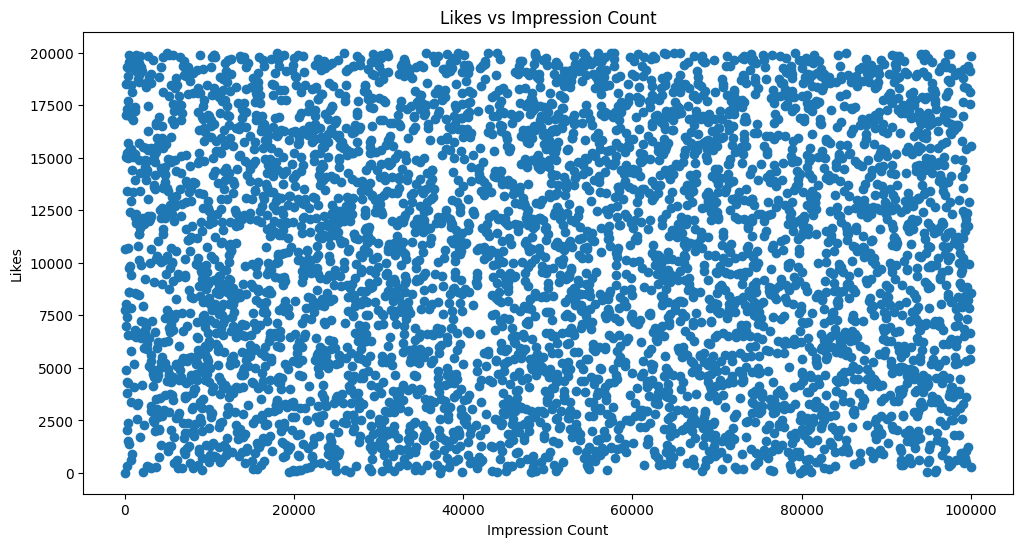

In [117]:
#Scatter Plot: likes vs impressions

plt.figure(figsize=(12, 6))
plt.scatter(df['impression_count'], df['likes'])
plt.title('Likes vs Impression Count')
plt.xlabel('Impression Count')
plt.ylabel('Likes')

plt.show()


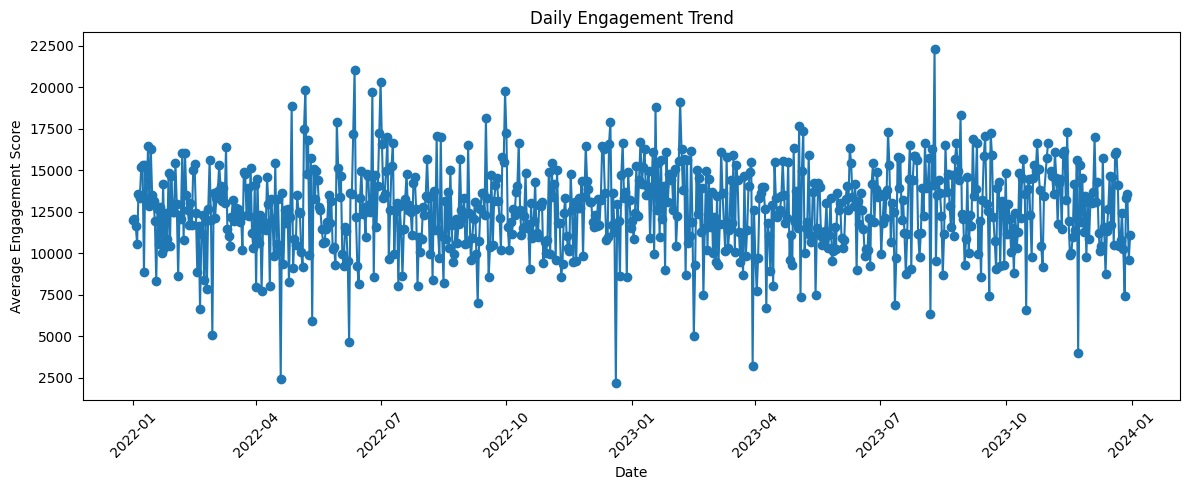

In [103]:
#Line Plot: daily engagement trend

df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")
daily_engagement = (df.groupby(df["posted_at"].dt.date)["engagement_score"] .mean())
plt.figure(figsize=(12, 5))
plt.plot( daily_engagement.index,daily_engagement.values,marker="o")
plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

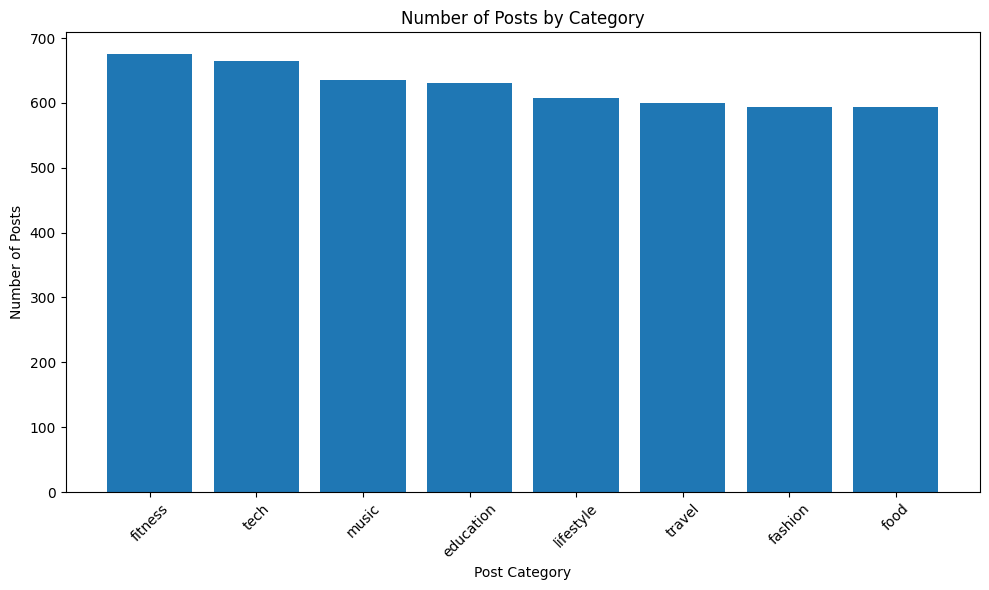

In [96]:
# Bar Plot: posts by category

category_counts = df["post_category"].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(category_counts.index,category_counts.values)
plt.title("Number of Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

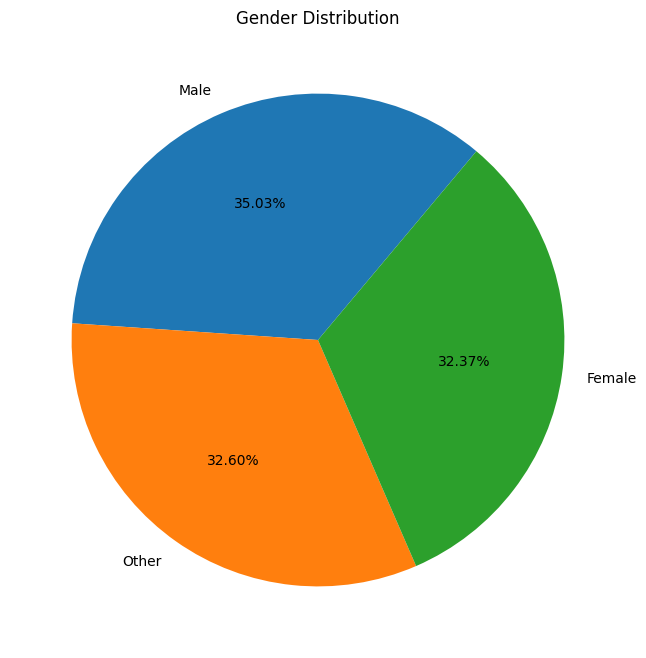

In [101]:
# Create pie chart

gender = df['gender'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(gender,labels=gender.index,autopct='%1.2f%%',startangle=50)
plt.title('Gender Distribution')
plt.show()

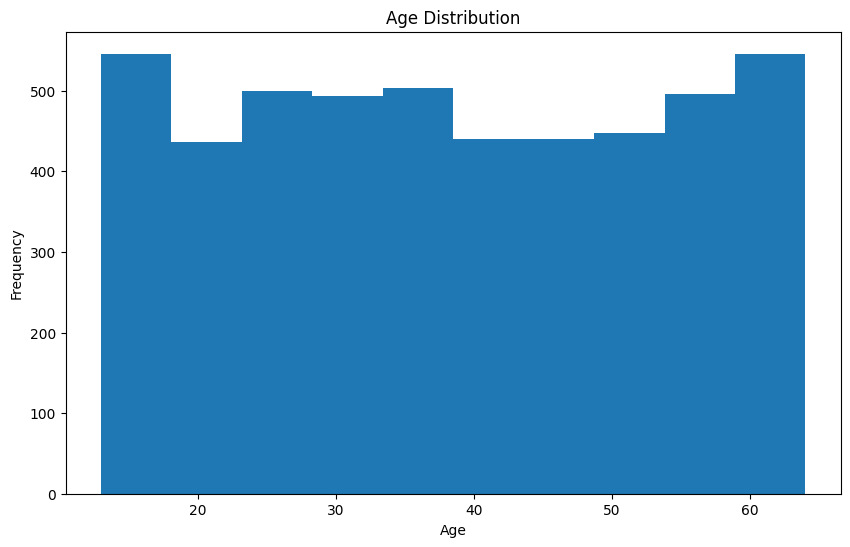

In [102]:
# Histogram: Age

plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

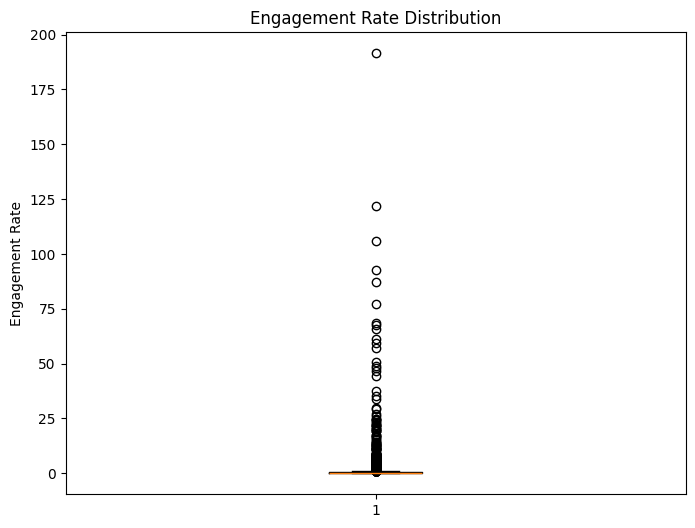

In [104]:
# Box Plot: Engagement Rate

plt.figure(figsize=(8, 6))
plt.boxplot(df['engagement_rate'].dropna(),vert=True)
plt.title('Engagement Rate Distribution')
plt.ylabel('Engagement Rate')

plt.show()

#**10) Data Visualization using Seaborn**

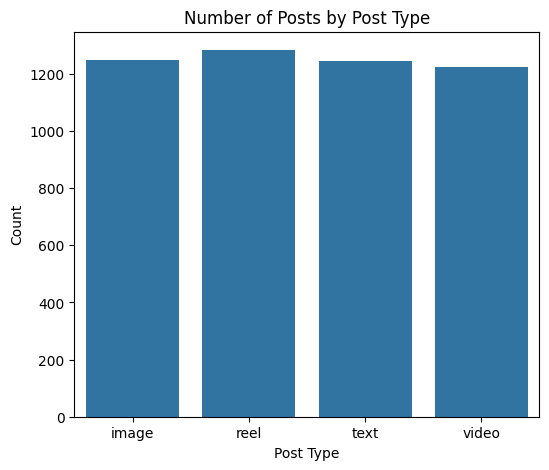

In [118]:
# Count Plot: Post Type

plt.figure(figsize=(6, 5))
sns.countplot(x=df['post_type'])
plt.title('Number of Posts by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Count')

plt.show()

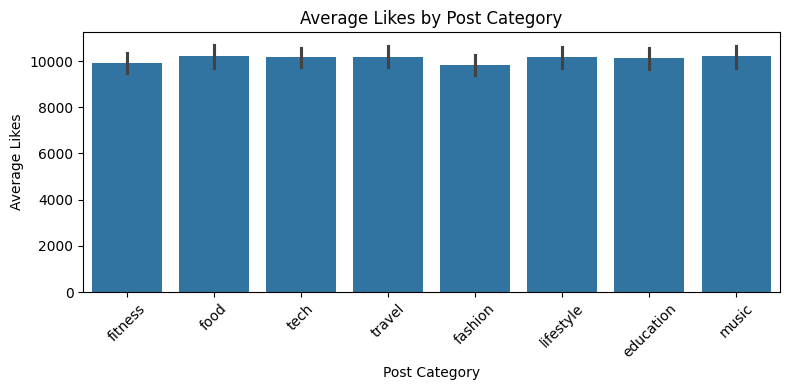

In [110]:
# Bar Plot: Average Likes by Category

plt.figure(figsize=(8, 4))

sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    estimator="mean"
)

plt.title("Average Likes by Post Category")
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

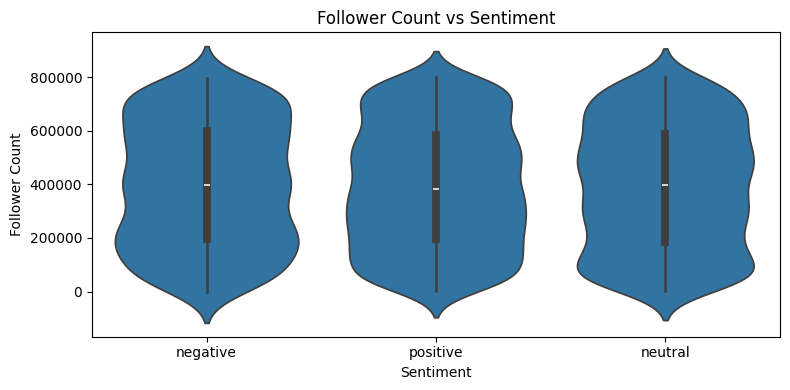

In [113]:
# Violin Plot — Followers vs Sentiment

plt.figure(figsize=(8, 4))
sns.violinplot(data=df,x="sentiment",y="follower_count")
plt.title("Follower Count vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.tight_layout()

plt.show()

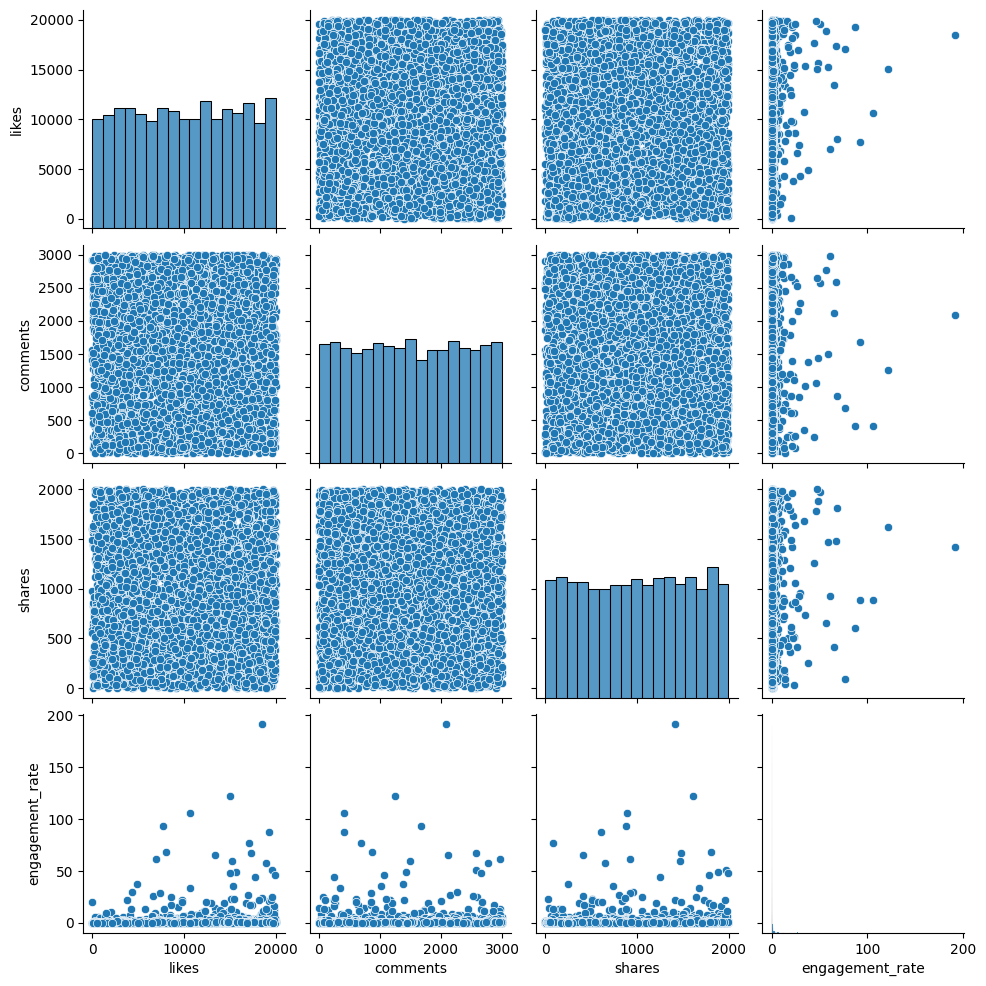

In [114]:
# Pair Plot — Numeric Features

numeric_features = ["likes", "comments","shares","engagement_rate"]
sns.pairplot(df[numeric_features].dropna())

plt.show()

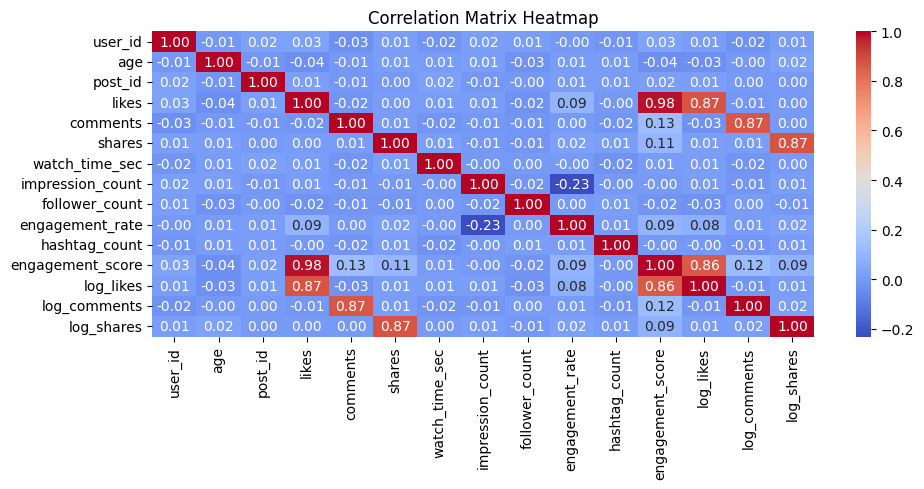

In [119]:
# Heatmap: correlation matrix

# First create the correlation matrix:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()

plt.show()

# **11) Final Insights**

## **(1) Content Performance**

In [138]:
# Which post types have the highest engagement?
df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False)

print(post_type_engagement)

post_type
video    1.122365
text     1.064549
image    0.895646
reel     0.783047
Name: engagement_rate, dtype: float64


In [124]:
# Best-performing content category?
df.groupby("post_category")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
post_category,
food,1.358628
tech,1.160475
lifestyle,1.091019
music,0.888803
fitness,0.865628
education,0.844222
fashion,0.807109
travel,0.702223


In [131]:
# Which countries have the highest average engagement rate?
df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


## **(2) User Trends**

In [140]:
# How age affects engagement

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['age_group'] = pd.cut(df['age'],bins=bins,labels=labels)

age_engagement = (df.groupby('age_group', observed=True)['engagement_rate'].mean())
print(age_engagement)

age_group
<18      0.867038
18-25    1.059536
26-35    0.865316
36-45    0.858642
46-55    1.414058
56-65    0.709213
Name: engagement_rate, dtype: float64


In [144]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count', 'engagement_score', 'log_likes', 'log_comments', 'log_shares', 'age_group']


In [145]:
# Performance difference for verified accounts
verified_engagement =(df.groupby('is_verified')['engagement_rate'].mean())

print(verified_engagement)

is_verified
False    0.954744
True     1.054250
Name: engagement_rate, dtype: float64


## **(3) Behavioral Insights**

In [154]:
# Best time of day for impressions
# Convert posted_at to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'])

# Extract hour from posted_at
df['hour'] = df['posted_at'].dt.hour

# Calculate average impressions by hour
hourly_impressions = (df.groupby('hour')['impression_count'].mean().sort_values(ascending=False))

print(hourly_impressions)

hour
0    50013.7328
Name: impression_count, dtype: float64


In [148]:
# Device type impact on watch time
df.groupby("device_type")["watch_time_sec"].mean().sort_values(ascending=False)

,watch_time_sec
device_type,
mobile,4087.830760
tablet,3979.736429
desktop,3974.792521


## **(4) Sentiment Analysis**

In [149]:
# Which sentiment performs best
df.groupby("sentiment")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.954800


In [150]:
# Behavior of negative/neutral sentiment posts
df[df["sentiment"].isin(["negative", "neutral"])].groupby("sentiment")[["likes", "comments", "shares", "impression_count", "engagement_rate"]].mean()

,likes,comments,shares,impression_count,engagement_rate
sentiment,,,,,
negative,10211.406452,1516.584402,1007.186966,50191.960417,1.038486
neutral,9917.785570,1529.270525,996.149966,49515.971185,0.991170


# **12) Conclusion**

This project demonstrates how Python can be used to perform an end-to-end social media engagement analysis. Through data cleaning, feature engineering, exploratory analysis, statistical techniques, visualization, and group-based comparisons, the project identified meaningful differences in engagement across post types, content categories, countries, age groups, verification status, device types, and sentiment.

The analysis shows that engagement behavior is influenced by multiple dimensions rather than a single factor. In this dataset, video content, food-related content, verified accounts, mobile usage, and negative-sentiment posts were associated with higher measured engagement rates.

The project also highlights an important data-quality principle: insights are only as reliable as the underlying data. In particular, the posting-time analysis demonstrates why complete timestamp information is necessary before making conclusions about the best time to publish content.

Overall, the project provides practical experience in using Pandas, NumPy, Matplotlib, and Seaborn to convert raw social media data into structured analysis and business-oriented insights.